# 13 — Đánh giá tổng quát hóa: Walk-forward CV theo thời gian (có embargo)

**Câu hỏi notebook này trả lời:** một con số PR-AUC trên *một* split (như nb10/nb12) có đáng tin không? Model **tổng quát hóa** ra các giai đoạn thời gian khác nhau tới đâu?

**Bối cảnh (từ nb12):** test PR-AUC (0.377) **cao hơn** val PR-AUC (0.311) — tức cửa sổ val khó hơn test. Một split đơn lẻ do đó **đánh giá sai** khả năng tổng quát hóa: rơi vào khúc thời gian dễ thì số đẹp, khúc khó thì số xấu. Ta cần **nhiều fold thời gian** để đọc *phân phối* PR-AUC, không chỉ một điểm.

## Chọn phương pháp CV — vì sao *walk-forward theo `step` + embargo*, không phải cái khác

| Phương pháp | Hợp không | Lý do |
|---|---|---|
| KFold / random | ❌ | Trộn tương lai vào train → rò rỉ, điểm đẹp giả. |
| `TimeSeriesSplit` (sklearn) | ⚠️ gần đúng | Đúng hướng thời gian nhưng cắt theo **chỉ số dòng**, không theo `step`. Các event **cùng một step** (cùng thời điểm) bị xé qua ranh giới train/test. Không có embargo. |
| Purged **Group** Time Split | ⚠️ một phần | *Purge forward-label* KHÔNG cần: nhãn `isFraud` là **điểm-thời-gian**, không chân trời tương lai → không có gì để purge. NHƯNG *group theo entity* nhắm đúng một thứ **có thật**: trùng recipient giữa train/test tạo phụ thuộc mẫu. Ta không tách group cứng (production vẫn chấm lại recipient cũ), mà **đo trực tiếp** bằng lát cắt warm/cold ở **Phần 2**. |
| **Walk-forward theo `step` + embargo** ✅ | **Hợp nhất** | Train quá khứ (`step ≤ c`) → test tương lai (`c < step ≤ c+W`), cắt theo **thời gian thật**. `scale_pos_weight` tính lại **mỗi fold** (không rò rỉ prevalence toàn cục). Embargo = đo mức **phụ thuộc kề-thời-gian** (xem dưới). |

### Embargo ở đây đo gì? — KHÔNG phải chống rò rỉ tương lai

Nhãn ta điểm-thời-gian → **không** có future leakage (thứ tự thời gian luôn được giữ). Nhưng có một loại "lẫn" khác, tinh tế: một val-event **sát ranh giới** tính feature từ cửa sổ quá khứ **trùng** giai đoạn train, và **cùng một recipient** xuất hiện cả hai bên → val **phụ thuộc** train (*sample dependence*). Đây không phải rò rỉ tương lai, mà là câu hỏi *"ước lượng này lạc quan tới mức nào so với một giai đoạn độc lập?"*.

- **E=0** = ước lượng **production-realistic** — production cũng chấm-ngay dựa quá khứ gần, nên overlap là *hiện thực*, không phải lỗi.
- **E>0** = chừa khoảng đệm `E` step phá phụ thuộc kề-thời-gian → ước lượng **bảo thủ** (tôn trọng độc lập hơn).
- **Khoảng cách E=0 vs E=168** = mức model **dựa vào** overlap sát ranh giới. Gap ≈ 0 → không dựa nhiều, số production-realistic đáng tin. Gap lớn → số E=0 lạc quan.

(168 = 1 tuần, chỉ là khoảng đệm hợp lý; quan trọng là *so E=0 với E>0*, không phải giá trị cụ thể của E. Embargo phá phụ thuộc **kề-thời-gian**; phụ thuộc **trùng-entity** thì Phần 2 đo bằng warm/cold.)

## PHẦN 1 · Walk-forward CV qua các giai đoạn thời gian

> **Exploratory / non-promotable.** Đây là notebook học cách *đo tổng quát hóa*. Bản chốt contract chạy `training/` với manifest + đa seed (AGENTS §5/§6). Tag MLflow `manifest_backed=false`.

📖 **Cell dưới — Setup** (giống nb10–12) + `DEPLOYABLE_CORE`. In `READY`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from pit_fintech.config import get_settings
from pit_fintech.data.paysim import connect_paysim, find_paysim_csv, resolve_project_root
from pit_fintech.features.paysim_specs import PAYSIM_MODEL_FEATURE_ORDER

PIT12 = list(PAYSIM_MODEL_FEATURE_ORDER)
DEPLOYABLE_CORE = [
    "current_amount",
    "transaction_type_transfer",
    "pit_prior_amount_1h",
    "pit_prior_amount_24h",
    "pit_prior_amount_168h",
    "pit_prior_count_1h",
    "pit_prior_count_24h",
]

PROJECT_ROOT = resolve_project_root(Path.cwd())
settings = get_settings()
data_root = settings.data_root
if not data_root.is_absolute():
    data_root = PROJECT_ROOT / data_root
artifact_root = settings.artifact_root
if not artifact_root.is_absolute():
    artifact_root = PROJECT_ROOT / artifact_root

paysim_csv = find_paysim_csv(PROJECT_ROOT)
gold_base = data_root / "lakehouse" / "paysim1"
gold_candidates = (
    sorted(gold_base.glob("*/gold/pre_decision_features")) if gold_base.exists() else []
)
GOLD_PRE_PATH = next((p for p in gold_candidates if (p / "_delta_log").exists()), None)

LABELS_PATH = None
try:
    from pit_fintech.data.paysim_lakehouse import (
        ApplicationLakehouseManifest,
        _resolve_manifest_path,
        find_latest_paysim_lakehouse_manifest,
    )

    manifest_path = find_latest_paysim_lakehouse_manifest(artifact_root)
    if manifest_path is not None:
        manifest = ApplicationLakehouseManifest.model_validate_json(
            manifest_path.read_text(encoding="utf-8")
        )
        for snap in manifest.tables:
            if snap.table == "paysim_labels":
                LABELS_PATH = _resolve_manifest_path(snap.path, PROJECT_ROOT)
                break
except Exception as exc:
    print(f"label resolution skipped: {exc}")

READY = (
    paysim_csv is not None
    and GOLD_PRE_PATH is not None
    and LABELS_PATH is not None
    and (LABELS_PATH / "_delta_log").exists()
)
print({"ready": READY})

{'ready': True}


## Execution control

📖 **Cell dưới.** `RUN_CV` gate phần nặng. `BEST_PARAMS` = config tuned ở nb11 (đánh giá đúng model ta sẽ ship). `CUTS` = các mốc ranh giới train/test theo `step`; `TEST_WIDTH` = độ rộng cửa sổ test; `EMBARGOS=[0,168]` để so có/không khoảng trống.

In [2]:
RUN_CV = True
SEED = 20_260_727
FEATURES = DEPLOYABLE_CORE

# tuned tu nb11 (dan lai neu ban chay lai tuning)
BEST_PARAMS = dict(
    n_estimators=500,
    learning_rate=0.023049834751583245,
    num_leaves=38,
    max_depth=6,
    min_child_samples=100,
    subsample=0.6865787700518957,
    colsample_bytree=0.7680757154795024,
    reg_lambda=5.303612526311521,
)

CUTS = [360, 440, 520, 600, 680]  # ranh gioi train/test theo step
TEST_WIDTH = 55  # test = (cut, cut+55]
EMBARGOS = [0, 168]  # 0=production-realistic, 168=bao thu (khoang dem 1 tuan)

LOG_TO_MLFLOW = True
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
MLFLOW_EXPERIMENT = "pit-fintech-notebook-exploration"
print(f"{len(CUTS)} fold | test_width={TEST_WIDTH} | embargos={EMBARGOS} | feats={len(FEATURES)}")

5 fold | test_width=55 | embargos=[0, 168] | feats=7


📖 **Cell dưới — Nạp `frame`** (DuckDB join có `ORDER BY`, giống nb10–12). Không cần chia sẵn split — bộ chia walk-forward tự cắt theo `step`.

In [3]:
frame = None
if RUN_CV and READY:
    from deltalake import DeltaTable

    gold = DeltaTable(str(GOLD_PRE_PATH)).to_pyarrow_table()
    labels = (
        DeltaTable(str(LABELS_PATH)).to_pyarrow_table().select(["source_row_number", "isFraud"])
    )
    connection = connect_paysim(paysim_csv)
    connection.register("gold", gold)
    connection.register("labels", labels)
    pit_cols = ", ".join(f"g.{name}" for name in PIT12)
    frame = connection.execute(
        f"SELECT g.source_row_number, g.step, l.isFraud, {pit_cols} "
        "FROM gold AS g JOIN labels AS l USING (source_row_number) "
        "ORDER BY g.source_row_number"
    ).df()
    connection.close()
    frame[PIT12] = frame[PIT12].astype("float64")
    print(
        f"rows={len(frame):,} | step range=[{frame['step'].min()},{frame['step'].max()}] | "
        f"fraud={int(frame['isFraud'].sum()):,}"
    )
else:
    print("Skipped: set RUN_CV = True (và data READY).")

rows=2,770,409 | step range=[1,743] | fraud=8,213


## Bộ chia walk-forward + embargo

📖 **Cell dưới — Định nghĩa splitter & fit-eval.** Với mốc `c`:
- **train** = `step ≤ c - E` (bỏ `E` step sát ranh giới = embargo)
- **test**  = `c < step ≤ c + TEST_WIDTH`

`scale_pos_weight = √(neg/pos)` tính **trên train của fold đó** (không dùng prevalence toàn cục — đó sẽ là rò rỉ). Mỗi fold trả PR-AUC + recall@FPR=1% + prevalence. Bỏ qua fold nào test không có đủ cả 2 lớp.

In [4]:
folds_result = None
if frame is not None:
    import lightgbm as lgb
    from sklearn.metrics import average_precision_score, roc_curve

    FIXED = dict(
        objective="binary",
        subsample_freq=1,
        deterministic=True,
        force_row_wise=True,
        seed=SEED,
        n_jobs=-1,
        verbose=-1,
    )

    def fit_eval(tr, te):
        pos = int((tr["isFraud"] == 1).sum())
        neg = int((tr["isFraud"] == 0).sum())
        spw = float(np.sqrt(neg / max(pos, 1)))
        mdl = lgb.LGBMClassifier(scale_pos_weight=spw, **BEST_PARAMS, **FIXED)
        mdl.fit(tr[FEATURES], tr["isFraud"])
        y = te["isFraud"].to_numpy()
        p = mdl.predict_proba(te[FEATURES])[:, 1]
        ap = float(average_precision_score(y, p))
        fpr, tpr, _ = roc_curve(y, p)
        rec_fpr1 = float(tpr[int(np.max(np.where(fpr <= 0.01)))])
        return ap, rec_fpr1, spw

    rows = []
    for E in EMBARGOS:
        for c in CUTS:
            tr = frame[frame["step"] <= c - E]
            te = frame[(frame["step"] > c) & (frame["step"] <= c + TEST_WIDTH)]
            yte = te["isFraud"]
            if len(tr) == 0 or len(te) == 0 or yte.nunique() < 2:
                continue
            ap, rec, spw = fit_eval(tr, te)
            rows.append(
                {
                    "embargo": E,
                    "cut": c,
                    "train_rows": len(tr),
                    "test_rows": len(te),
                    "test_fraud": int(yte.sum()),
                    "prevalence": round(float(yte.mean()), 5),
                    "pr_auc": round(ap, 6),
                    "recall_at_fpr1": round(rec, 6),
                }
            )
    folds_result = pd.DataFrame(rows)
    display(folds_result)
else:
    print("Skipped: enable RUN_CV above.")

,embargo,cut,train_rows,test_rows,test_fraud,prevalence,pr_auc,recall_at_fpr1
0,0,360,2264898,351191,682,0.00194,0.277675,0.500000
1,0,440,2624130,18660,560,0.03001,0.510471,0.376786
2,0,520,2653729,48563,578,0.01190,0.293754,0.278547
3,0,600,2726859,9309,622,0.06682,0.476917,0.289389
4,0,680,2741949,28366,620,0.02186,0.337917,0.300000
5,168,360,1044838,351191,682,0.00194,0.255368,0.504399
6,168,440,1580958,18660,560,0.03001,0.494281,0.391071
7,168,520,2185198,48563,578,0.01190,0.276208,0.290657
8,168,600,2623890,9309,622,0.06682,0.472804,0.289389
9,168,680,2646689,28366,620,0.02186,0.335578,0.300000


📖 **Cell dưới — Tóm tắt theo embargo:** mean ± std của PR-AUC & recall@FPR qua các fold, cho từng mức embargo. Đây là con số *tổng quát hóa* thật sự (thay vì 1 điểm).

In [5]:
summary = None
if folds_result is not None and len(folds_result):
    summary = (
        folds_result.groupby("embargo")
        .agg(
            folds=("cut", "count"),
            pr_auc_mean=("pr_auc", "mean"),
            pr_auc_std=("pr_auc", "std"),
            pr_auc_min=("pr_auc", "min"),
            pr_auc_max=("pr_auc", "max"),
            recall_fpr1_mean=("recall_at_fpr1", "mean"),
        )
        .round(6)
        .reset_index()
    )
    display(summary)
    if len(summary) >= 2:
        d = summary.set_index("embargo")["pr_auc_mean"]
        if 0 in d.index and 168 in d.index:
            print(
                f"Δ PR-AUC (embargo 168 - 0) = {d[168] - d[0]:+.6f}  "
                f"-> gan 0 nghia la nhan KHONG ro ri qua ranh gioi (khop future-read=0)"
            )
else:
    print("Skipped: enable RUN_CV above.")

,embargo,folds,pr_auc_mean,pr_auc_std,pr_auc_min,pr_auc_max,recall_fpr1_mean
0,0,5,0.379347,0.107347,0.277675,0.510471,0.348944
1,168,5,0.366848,0.110778,0.255368,0.494281,0.355103


Δ PR-AUC (embargo 168 - 0) = -0.012499  -> gan 0 nghia la nhan KHONG ro ri qua ranh gioi (khop future-read=0)


📖 **Cell dưới — Biểu đồ PR-AUC qua các fold** (một đường cho mỗi embargo) + dải mean±std. Nhìn *độ dao động* theo thời gian: đó chính là mức không chắc chắn mà một split đơn lẻ giấu đi.

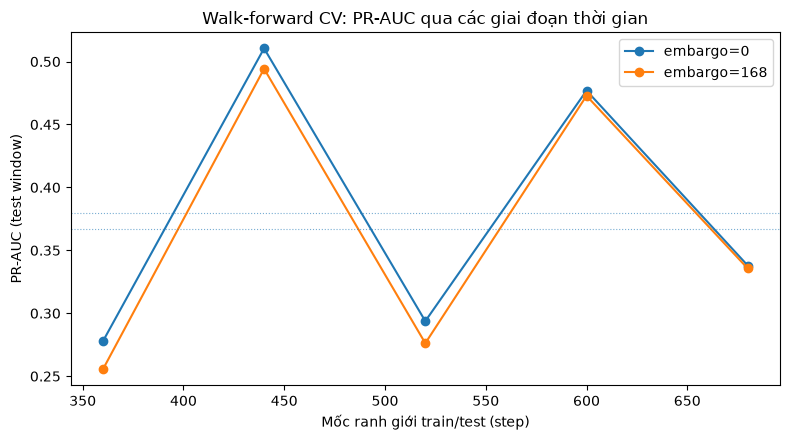

In [6]:
if folds_result is not None and len(folds_result):
    try:
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=(8, 4.5))
        for E, grp in folds_result.groupby("embargo"):
            grp = grp.sort_values("cut")
            ax.plot(grp["cut"], grp["pr_auc"], marker="o", label=f"embargo={E}")
            m = grp["pr_auc"].mean()
            ax.axhline(m, ls=":", lw=0.8, alpha=0.6)
        ax.set_xlabel("Mốc ranh giới train/test (step)")
        ax.set_ylabel("PR-AUC (test window)")
        ax.set_title("Walk-forward CV: PR-AUC qua các giai đoạn thời gian")
        ax.legend()
        fig.tight_layout()
        plt.show()
    except ImportError:
        print("matplotlib unavailable; dung bang o tren.")
else:
    print("Skipped: enable RUN_CV above.")

## PHẦN 2 · Phụ thuộc trùng-entity: recipient CŨ (warm) vs MỚI (cold)

📖 **Câu hỏi.** Embargo phá phụ thuộc *kề-thời-gian*, nhưng **trùng recipient** giữa train/test là loại phụ thuộc khác: nếu model "nhớ" hành vi của một recipient đã thấy khi train, nó có thể được điểm cao trên đúng recipient đó ở test → số **lạc quan cho recipient mới**.

**Cách đo (đúng thời gian, không phá temporal):** trong mỗi fold temporal, chia test làm 2 lát:
- **warm** = recipient **có lịch sử gần** (`pit_prior_count_168h > 0`) — recurring, giống train.
- **cold** = recipient **không có lịch sử gần** (`= 0`) — mới/cold-start, gần với "recipient chưa từng thấy".

Nếu **PR-AUC(cold) ≪ PR-AUC(warm)** → model dựa nhiều vào tín hiệu recurring-entity → số tổng thể lạc quan cho entity mới. Nếu gần nhau → model tổng quát hóa tốt sang recipient mới.

> *Caveat trung thực:* "cold" theo lịch sử-168h là **xấp xỉ** "recipient chưa từng thấy" (một recipient cold vẫn có thể xuất hiện >168h trước). Nhưng cold = ca cold-start khó, đúng thứ đáng lo. Đây cũng chính là các lát `cash_out_cold / transfer_cold` mà ADR-002 nhắc tới.

In [7]:
entity_result = None
if frame is not None:
    import lightgbm as lgb
    from sklearn.metrics import average_precision_score

    WARM_COL = "pit_prior_count_168h"
    if WARM_COL not in frame.columns:
        cands = [c for c in frame.columns if "168" in c and ("count" in c or "history" in c)]
        WARM_COL = cands[0] if cands else None

    if WARM_COL is None:
        print("Khong tim thay cot lich su 168h -> bo qua warm/cold.")
    else:
        rows = []
        for c in CUTS:
            tr = frame[frame["step"] <= c]
            te = frame[(frame["step"] > c) & (frame["step"] <= c + TEST_WIDTH)]
            if len(tr) == 0 or len(te) == 0:
                continue
            pos = int((tr["isFraud"] == 1).sum())
            neg = int((tr["isFraud"] == 0).sum())
            spw = float(np.sqrt(neg / max(pos, 1)))
            mdl = lgb.LGBMClassifier(scale_pos_weight=spw, **BEST_PARAMS, **FIXED)
            mdl.fit(tr[FEATURES], tr["isFraud"])
            te = te.copy()
            te["_p"] = mdl.predict_proba(te[FEATURES])[:, 1]
            for kind, sub in [("warm", te[te[WARM_COL] > 0]), ("cold", te[te[WARM_COL] == 0])]:
                y = sub["isFraud"]
                ap = (
                    round(float(average_precision_score(y, sub["_p"])), 6)
                    if len(sub) and y.nunique() == 2
                    else None
                )
                rows.append(
                    {
                        "cut": c,
                        "segment": kind,
                        "rows": len(sub),
                        "fraud": int(y.sum()),
                        "prevalence": round(float(y.mean()), 5) if len(sub) else None,
                        "pr_auc": ap,
                    }
                )
        entity_result = pd.DataFrame(rows)
        display(entity_result)
        good = entity_result.dropna(subset=["pr_auc"])
        if len(good):
            print(good.groupby("segment")["pr_auc"].agg(["mean", "std", "count"]).round(6))
else:
    print("Skipped: enable RUN_CV above.")

,cut,segment,rows,fraud,prevalence,pr_auc
0,360,warm,297210,237,0.00080,0.364611
1,360,cold,53981,445,0.00824,0.210105
2,440,warm,14371,185,0.01287,0.480444
3,440,cold,4289,375,0.08743,0.476042
4,520,warm,25600,127,0.00496,0.397945
5,520,cold,22963,451,0.01964,0.254908
6,600,warm,2172,59,0.02716,0.391720
7,600,cold,7137,563,0.07888,0.479064
8,680,warm,6126,50,0.00816,0.406821
9,680,cold,22240,570,0.02563,0.327579


             mean       std  count
segment                           
cold     0.349540  0.124156      5
warm     0.408308  0.043295      5


📖 **Cách đọc warm/cold.**
- **PR-AUC(cold) gần PR-AUC(warm)** → model đọc được fraud cả trên recipient mới → tổng quát hóa tốt, số tổng thể không phụ thuộc "đã thấy entity".
- **cold ≪ warm** → model chủ yếu ăn tín hiệu recurring-entity → recipient mới bị phục vụ kém, và số tổng thể **lạc quan** cho cold-start. Đây là lúc cân nhắc feature cold-start (Track B, cần ADR + v3).
- Đối chiếu với `recall_at_fpr1` embargo ở Phần 1: hai góc nhìn phụ thuộc (kề-thời-gian & trùng-entity) bổ sung cho nhau.

📖 **Cell dưới — Log lên MLflow.** Parent `nb13-walkforward-cv` (metric tóm tắt: mean/std/min/max PR-AUC mỗi embargo) + nested run mỗi fold. Tag `manifest_backed=false`.

In [8]:
if folds_result is not None and len(folds_result) and LOG_TO_MLFLOW:
    try:
        import mlflow

        mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
        mlflow.set_experiment(MLFLOW_EXPERIMENT)
        with mlflow.start_run(run_name="nb13-walkforward-cv"):
            mlflow.log_params(
                {
                    "features": ",".join(FEATURES),
                    "cuts": str(CUTS),
                    "test_width": TEST_WIDTH,
                    "embargos": str(EMBARGOS),
                    "seed": SEED,
                    **{f"hp_{k}": v for k, v in BEST_PARAMS.items()},
                }
            )
            for _, r in summary.iterrows():
                e = int(r["embargo"])
                mlflow.log_metric(f"pr_auc_mean_emb{e}", float(r["pr_auc_mean"]))
                mlflow.log_metric(f"pr_auc_std_emb{e}", float(r["pr_auc_std"]))
                mlflow.log_metric(f"recall_fpr1_mean_emb{e}", float(r["recall_fpr1_mean"]))
            for _, r in folds_result.iterrows():
                with mlflow.start_run(
                    nested=True, run_name=f"fold-emb{int(r['embargo'])}-cut{int(r['cut'])}"
                ):
                    mlflow.log_params(
                        {
                            "embargo": int(r["embargo"]),
                            "cut": int(r["cut"]),
                            "train_rows": int(r["train_rows"]),
                            "test_rows": int(r["test_rows"]),
                        }
                    )
                    mlflow.log_metric("pr_auc", float(r["pr_auc"]))
                    mlflow.log_metric("recall_at_fpr1", float(r["recall_at_fpr1"]))
                    mlflow.log_metric("prevalence", float(r["prevalence"]))
                    mlflow.set_tags(
                        {
                            "surface": "notebook-exploratory",
                            "manifest_backed": "false",
                            "stage": "cv-fold",
                        }
                    )
            mlflow.set_tags(
                {
                    "surface": "notebook-exploratory",
                    "manifest_backed": "false",
                    "stage": "walkforward-cv",
                }
            )
        print("Logged -> nb13-walkforward-cv @", MLFLOW_TRACKING_URI)
    except Exception as exc:
        print(f"mlflow log skipped: {exc}")
else:
    print("MLflow off hoặc chưa có kết quả.")

C:\workspace\pit-fintech\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🏃 View run fold-emb0-cut360 at: http://127.0.0.1:5000/#/experiments/6/runs/f9ee69a953254ab9bf6f732e07aa5fce
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
🏃 View run fold-emb0-cut440 at: http://127.0.0.1:5000/#/experiments/6/runs/2f5465d28b8640a4a330ee738b6c9ee8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
🏃 View run fold-emb0-cut520 at: http://127.0.0.1:5000/#/experiments/6/runs/c77f4262adbe458e83df21b944210abe
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
🏃 View run fold-emb0-cut600 at: http://127.0.0.1:5000/#/experiments/6/runs/ada6f8c163b54f19b9c1487f0a11b5e2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
🏃 View run fold-emb0-cut680 at: http://127.0.0.1:5000/#/experiments/6/runs/89d89121df1a415abf5d867a9eab8dd8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/6
🏃 View run fold-emb168-cut360 at: http://127.0.0.1:5000/#/experiments/6/runs/d5601fb04b40469faf1d42d6f6170c9a
🧪 View experiment at: http://127.0.0.1:5000/#/expe

## Cách đọc & kết luận

📖 **Phần 1 — biến thiên qua thời gian:**
- **`pr_auc_std` nhỏ so với `pr_auc_mean`** → model *ổn định qua thời gian*, số nb12 đáng tin. **`std` lớn** → PR-AUC dao động mạnh → một split đơn lẻ (nb10/12) chỉ là *may rủi của một khúc thời gian*; phải báo cáo **mean ± std**, không phải một điểm.
- **`pr_auc_min`** = kịch bản xấu nhất qua các giai đoạn — "đáy" đáng lo cho vận hành, không phải test đơn lẻ.
- **`prevalence` mỗi fold khác nhau** → PR-AUC phải đọc kèm prevalence (sàn = prevalence). Fold prevalence thấp có PR-AUC tuyệt đối thấp nhưng **lift** có thể cao — đừng so tuyệt đối giữa các fold khác prevalence một cách ngây thơ.

📖 **Δ embargo — phụ thuộc kề-thời-gian:**
- **Δ PR-AUC(E=168 − 0) ≈ 0 (âm nhẹ)** → model **không** dựa nhiều vào overlap sát ranh giới → ước lượng production-realistic (E=0) không bị thổi phồng. Đây KHÔNG phải "chứng minh không có future leakage" (chuyện đó do hợp đồng PIT + `tests/temporal` lo); nó đo *mức phụ thuộc mẫu* và cho biết số E=0 lạc quan tới đâu.
- Nếu Δ **âm mạnh** → model đang ăn overlap → số E=0 lạc quan, lấy E=168 làm ước lượng thật.

📖 **Phần 2 — phụ thuộc trùng-entity (warm/cold):**
- **cold ≈ warm** → tổng quát hóa tốt sang recipient mới. **cold ≪ warm** → model ăn tín hiệu recurring-entity, cold-start bị phục vụ kém, số tổng thể lạc quan cho entity mới.

📖 **Chốt:**
- Trả lời đúng cho "test > val ở nb12": **đo trên nhiều fold thời gian** thay vì tin một split (mean ± std + min).
- Phương pháp hợp nhất = **walk-forward theo `step`** + **embargo** (đo phụ thuộc kề-thời-gian) + **warm/cold** (đo phụ thuộc trùng-entity). *Không* cần Purged-Group cứng vì (a) nhãn không nhìn tương lai → không purge forward-label; (b) production chấm lại recipient cũ là hợp lệ — nhưng ta vẫn *đo* ảnh hưởng entity thay vì bỏ qua.
- Notebook **exploratory**; bản chốt promotable chạy `training/` với manifest + đa seed. Notebook này *thay* phần CV thô ở cuối nb10 (nb10 dùng `scale_pos_weight` full ratio; ở đây nhất quán `√(neg/pos)` + embargo + warm/cold).